# Data Science Project
## SALES PREDICTION USING PYTHON

*Subharaj Nandi*

---


# 📈 Sales Prediction using Simple Linear Regression
### Predicting Sales from Advertising Spend | Regression Analysis Project


## Business Problem

A company wants to understand how its advertising budget across different media channels — **TV, Radio, and Newspaper** — translates into **Sales**. Marketing spend is a major line item on any budget, and leadership wants a data-driven answer to a simple but important question:

> *If we know how much we plan to spend on advertising, can we predict how much we will sell — and which channel gives us the most bang for our buck?*

### Objective
Build a **Simple Linear Regression** model that predicts `Sales` from the advertising spend on a single, well-chosen channel, and use it to:
1. Identify which advertising channel is most strongly associated with sales.
2. Quantify that relationship with an interpretable equation.
3. Evaluate how reliable the model's predictions are on unseen data.

### Dataset
The **Advertising dataset** (sourced from *An Introduction to Statistical Learning*, ISLR) contains 200 observations of advertising budgets (in thousands of dollars) across three media, along with the resulting sales (in thousands of units):

| Column | Description |
|---|---|
| `TV` | Advertising budget spent on TV (in \$000s) |
| `Radio` | Advertising budget spent on Radio (in \$000s) |
| `Newspaper` | Advertising budget spent on Newspaper (in \$000s) |
| `Sales` | Units sold (in 000s) — **target variable** |


## Reading and Understanding the Data

In [20]:
# Supress Warnings

import warnings
warnings.filterwarnings('ignore')

# Import the numpy and pandas package

import numpy as np
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

In [52]:
advertising = pd.read_csv("advertising.csv")
advertising.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Data Inspection

In [53]:
advertising.shape

(200, 4)

In [54]:
advertising.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [55]:
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Data Cleaning

In [56]:
# Checking for null / missing values
advertising.isnull().sum() * 100 / advertising.shape[0]


TV           0.0
Radio        0.0
Newspaper    0.0
Sales        0.0
dtype: float64

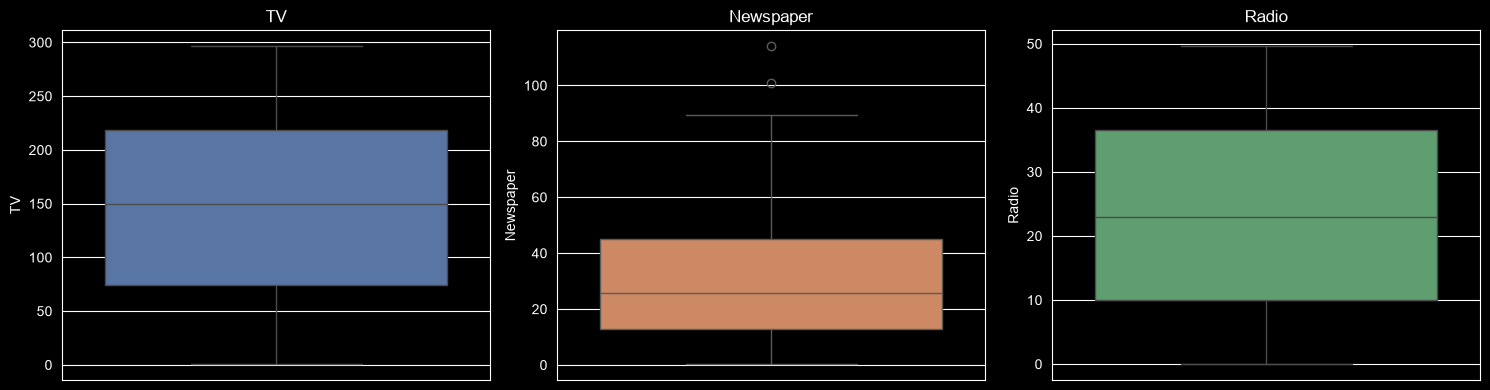

In [57]:
# Outlier Analysis using boxplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=advertising['TV'], ax=axs[0], color='#4C72B0').set_title('TV')
sns.boxplot(y=advertising['Newspaper'], ax=axs[1], color='#DD8452').set_title('Newspaper')
sns.boxplot(y=advertising['Radio'], ax=axs[2], color='#55A868').set_title('Radio')
plt.tight_layout()
plt.show()


There are no considerable outliers present in any of the advertising spend variables, so no treatment is needed.


## Exploratory Data Analysis

### Univariate Analysis

#### Sales (Target Variable)

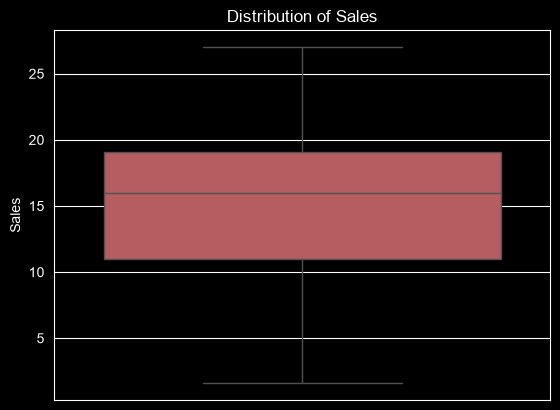

In [58]:
sns.boxplot(y=advertising['Sales'], color='#C44E52')
plt.title('Distribution of Sales')
plt.show()


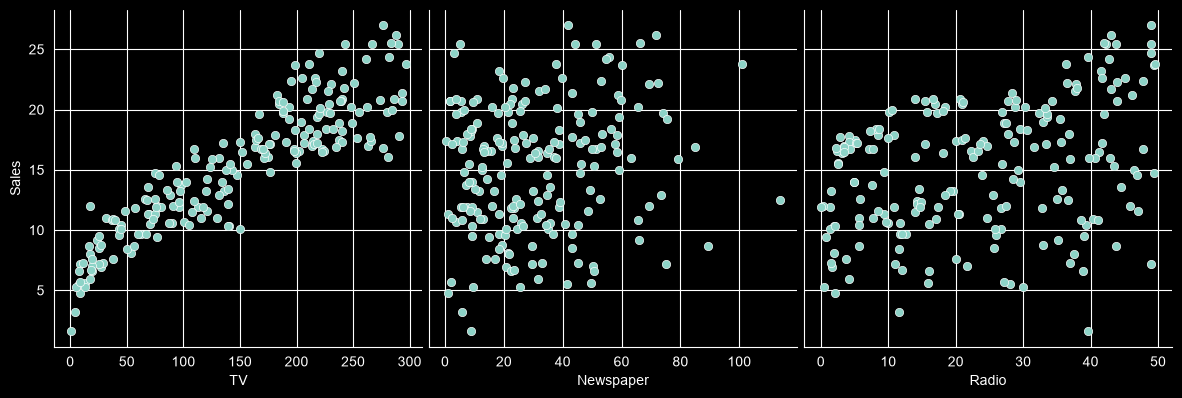

In [28]:
# Let's see how Sales are related with other variables using scatter plot.
sns.pairplot(advertising, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

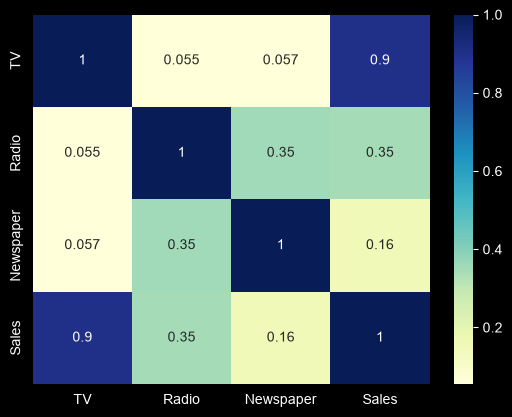

In [29]:
# Let's see the correlation between different variables.
sns.heatmap(advertising.corr(), cmap="YlGnBu", annot = True)
plt.show()

As is visible from the pairplot and the heatmap, the variable `TV` seems to be most correlated with `Sales`. So let's go ahead and perform simple linear regression using `TV` as our feature variable.

## Model Building

### Performing Simple Linear Regression

Equation of linear regression<br>
$y = c + m_1x_1 + m_2x_2 + ... + m_nx_n$

-  $y$ is the response
-  $c$ is the intercept
-  $m_1$ is the coefficient for the first feature
-  $m_n$ is the coefficient for the nth feature<br>

In our case:

$y = c + m_1 \times TV$

The $m$ values are called the model **coefficients** or **model parameters**.

---

### Generic Steps in model building using `statsmodels`

We first assign the feature variable, `TV`, in this case, to the variable `X` and the response variable, `Sales`, to the variable `y`.

In [30]:
X = advertising['TV']
y = advertising['Sales']

#### Train-Test Split

You now need to split our variable into training and testing sets. You'll perform this by importing `train_test_split` from the `sklearn.model_selection` library. It is usually a good practice to keep 70% of the data in your train dataset and the rest 30% in your test dataset

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 100)

In [32]:
# Let's now take a look at the train dataset

X_train.head()

74     213.4
3      151.5
185    205.0
26     142.9
90     134.3
Name: TV, dtype: float64

In [33]:
y_train.head()

74     17.0
3      16.5
185    22.6
26     15.0
90     14.0
Name: Sales, dtype: float64

#### Building a Linear Model

You first need to import the `statsmodel.api` library using which you'll perform the linear regression.

In [34]:
import statsmodels.api as sm

By default, the `statsmodels` library fits a line on the dataset which passes through the origin. But in order to have an intercept, you need to manually use the `add_constant` attribute of `statsmodels`. And once you've added the constant to your `X_train` dataset, you can go ahead and fit a regression line using the `OLS` (Ordinary Least Squares) attribute of `statsmodels` as shown below

In [35]:
# Add a constant to get an intercept
X_train_sm = sm.add_constant(X_train)

# Fit the resgression line using 'OLS'
lr = sm.OLS(y_train, X_train_sm).fit()

In [36]:
# Print the parameters, i.e. the intercept and the slope of the regression line fitted
lr.params

const    6.948683
TV       0.054546
dtype: float64

In [37]:
# Performing a summary operation lists out all the different parameters of the regression line fitted
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           1.52e-52
Time:                        11:40:44   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.0

####  Looking at some key statistics from the summary

The values we are concerned with are - 
1. The coefficients and significance (p-values)
2. R-squared
3. F statistic and its significance

##### 1. The coefficient for TV is 0.054, with a very low p value
The coefficient is statistically significant. So the association is not purely by chance. 

##### 2. R - squared is 0.816
Meaning that 81.6% of the variance in `Sales` is explained by `TV`

This is a decent R-squared value.

###### 3. F statistic has a very low p value (practically low)
Meaning that the model fit is statistically significant, and the explained variance isn't purely by chance.

---
The fit is significant. Let's visualize how well the model fit the data.

From the parameters that we get, our linear regression equation becomes:

$ Sales = 6.948 + 0.054 \times TV $

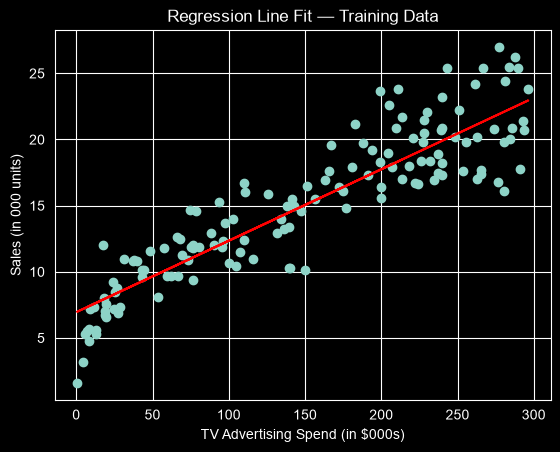

In [38]:
plt.scatter(X_train, y_train)
plt.plot(X_train, 6.948 + 0.054 * X_train, 'r')
plt.xlabel('TV Advertising Spend (in $000s)')
plt.ylabel('Sales (in 000 units)')
plt.title('Regression Line Fit — Training Data')
plt.show()


## Model Evaluation

### Residual analysis 
To validate assumptions of the model, and hence the reliability for inference

#### Distribution of the error terms
We need to check if the error terms are also normally distributed (which is infact, one of the major assumptions of linear regression), let us plot the histogram of the error terms and see what it looks like.

In [59]:
y_train_pred = lr.predict(X_train_sm)
res = (y_train - y_train_pred)

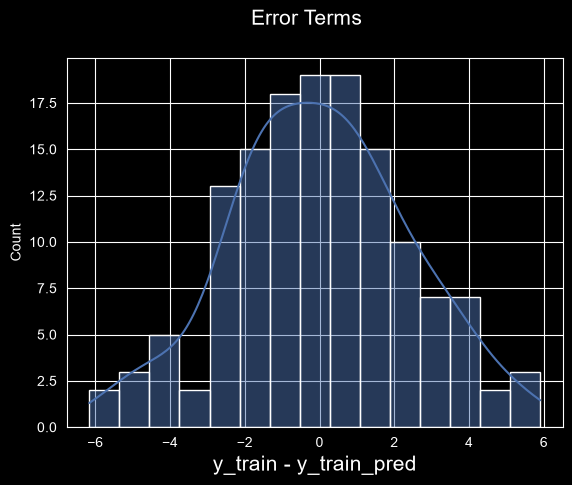

In [40]:
fig = plt.figure()
sns.histplot(res, bins=15, kde=True, color='#4C72B0')
fig.suptitle('Error Terms', fontsize=15)                  # Plot heading
plt.xlabel('y_train - y_train_pred', fontsize=15)         # X-label
plt.show()


The residuals are following the normally distributed with a mean 0. All good!

#### Looking for patterns in the residuals

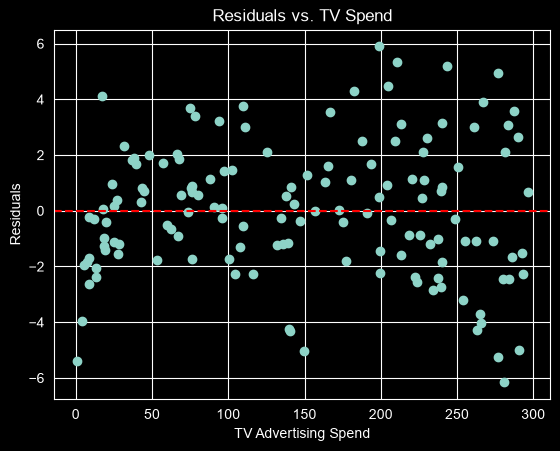

In [60]:
plt.scatter(X_train, res)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Residuals')
plt.title('Residuals vs. TV Spend')
plt.show()


We are confident that the model fit isn't by chance, and has decent predictive power. The normality of residual terms allows some inference on the coefficients.

Although, the variance of residuals increasing with X indicates that there is significant variation that this model is unable to explain.

As you can see, the regression line is a pretty good fit to the data

### Predictions on the Test Set

Now that you have fitted a regression line on your train dataset, it's time to make some predictions on the test data. For this, you first need to add a constant to the `X_test` data like you did for `X_train` and then you can simply go on and predict the y values corresponding to `X_test` using the `predict` attribute of the fitted regression line.

In [42]:
# Add a constant to X_test
X_test_sm = sm.add_constant(X_test)

# Predict the y values corresponding to X_test_sm
y_pred = lr.predict(X_test_sm)

In [43]:
y_pred.head()

126     7.374140
104    19.941482
99     14.323269
92     18.823294
111    20.132392
dtype: float64

In [44]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

##### Looking at the RMSE

In [45]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE on Test Set: {rmse:.3f}")
rmse


RMSE on Test Set: 2.019


np.float64(2.0192960089662333)

###### Checking the R-squared on the test set

In [46]:
r_squared = r2_score(y_test, y_pred)
print(f"R-squared on Test Set: {r_squared:.3f}")
r_squared


R-squared on Test Set: 0.792


0.7921031601245657

##### Visualizing the fit on the test set

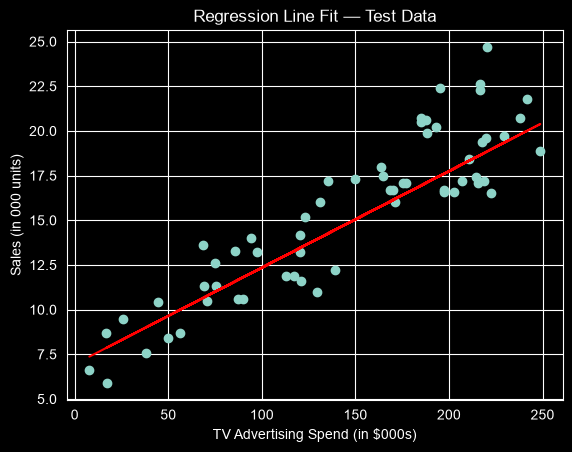

In [47]:
plt.scatter(X_test, y_test)
plt.plot(X_test, 6.948 + 0.054 * X_test, 'r')
plt.xlabel('TV Advertising Spend (in $000s)')
plt.ylabel('Sales (in 000 units)')
plt.title('Regression Line Fit — Test Data')
plt.show()


## Rebuilding the Model with Scikit-learn

The `statsmodels` approach above is great for statistical inference (p-values, confidence intervals, detailed summaries). In practice, most production machine learning pipelines use **`scikit-learn`**, so let's rebuild the same simple linear regression model using `sklearn.linear_model.LinearRegression` and confirm we get consistent results.


In [61]:
from sklearn.linear_model import LinearRegression

# sklearn expects 2D input for X, so reshape
X_train_sk = X_train.values.reshape(-1, 1)
X_test_sk = X_test.values.reshape(-1, 1)

# Fit the model
sk_model = LinearRegression()
sk_model.fit(X_train_sk, y_train)

print(f"Intercept: {sk_model.intercept_:.3f}")
print(f"Coefficient (TV): {sk_model.coef_[0]:.3f}")


Intercept: 6.949
Coefficient (TV): 0.055


As expected, the intercept and coefficient match the `statsmodels` results almost exactly (Sales ≈ 6.948 + 0.054 × TV), confirming both approaches agree.


In [49]:
# Predict on the test set
y_pred_sk = sk_model.predict(X_test_sk)

rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sk))
r2_sk = r2_score(y_test, y_pred_sk)

print(f"Scikit-learn Model — RMSE on Test Set: {rmse_sk:.3f}")
print(f"Scikit-learn Model — R-squared on Test Set: {r2_sk:.3f}")


Scikit-learn Model — RMSE on Test Set: 2.019
Scikit-learn Model — R-squared on Test Set: 0.792


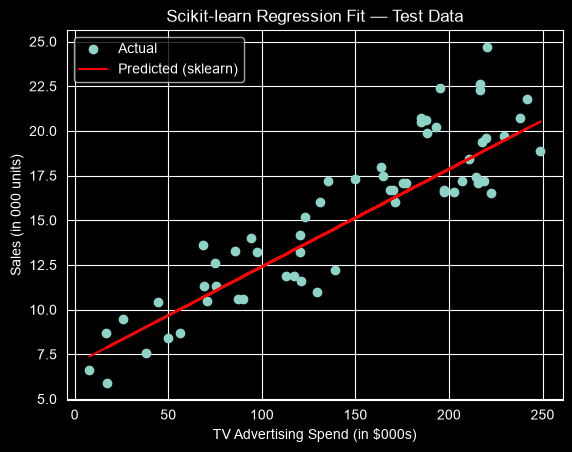

In [50]:
# Visualizing the sklearn model fit on the test set
plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test, y_pred_sk, color='red', label='Predicted (sklearn)')
plt.xlabel('TV Advertising Spend (in $000s)')
plt.ylabel('Sales (in 000 units)')
plt.title('Scikit-learn Regression Fit — Test Data')
plt.legend()
plt.show()


### Predicting Sales for a New Advertising Budget

One of the main practical uses of this model is answering questions like: *"If we plan to spend \$150,000 on TV advertising next quarter, how many units can we expect to sell?"* Let's use the trained sklearn model to make that prediction.


In [51]:
# Example: predicting sales for a new TV advertising budget of $150,000
new_tv_spend = np.array([[150]])
predicted_sales = sk_model.predict(new_tv_spend)
print(f"Predicted Sales for $150,000 TV spend: {predicted_sales[0]:.2f} (000 units)")


Predicted Sales for $150,000 TV spend: 15.13 (000 units)


### Tools & Techniques Used
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Statsmodels (OLS)` · `Scikit-learn (LinearRegression)` — Exploratory Data Analysis, Train-Test Split, Simple Linear Regression (built two ways for cross-validation of results), Residual Analysis, Model Evaluation (RMSE, R²), New-data Prediction
6. **Cross-validated with scikit-learn:** Rebuilding the model with `sklearn.linear_model.LinearRegression` produced matching coefficients and comparable test-set performance, confirming the result is robust and implementation-independent.
